# Uplift Modelling to estimate CATE 

## Overview
This project aims to estimate conditional average treatment effect (CATE) through uplift modelling on the Criteo A/B test dataset, predicting which users benefit most from receiving the treatment variant.The objective is to isolate and target the top 20% of persuadable customers in order to maximise conversion rates while optimising marketing budget.

## Dataset
The dataset is from https://ailab.criteo.com/criteo-uplift-prediction-dataset/. It contains 13M rows where each row represents one user and includes the following fields:
- f0-f11 (dense, float): 11 feature values
- treatment group (binary): 1 = treated and 0 = control 
- conversion (binary)
- visit (binary)
- exposure (binary): treatment effect (whether the use has been effectively exposed)

*In this project we use conversion as the outcome variable.*

## Models
- S-Learner vs NonParamDML (R-learner) — tuned with Optuna on validation set.

## Expected outcome
- A ranking of users by predicted CATE to decide: Treat the top 20% by predicted uplift to maximize business impact.

## Evaluation metrics
- Qini AUC
- Uplift at K %
- Average Treatment Effect (ATE)
- Decile Analysis
- CATE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings

from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.preprocessing import TargetEncoder
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.inspection import permutation_importance
from sklearn.exceptions import DataConversionWarning

from econml.metalearners import SLearner
from econml.dml import NonParamDML

import optuna
from sklift.metrics import qini_auc_score, qini_curve, perfect_qini_curve, uplift_by_percentile

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", message=".*force_all_finite.*", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

rng = np.random.default_rng(seed=321)

In [3]:

# CONFIGURATION
# ────────────────────────────────────────────────────────────────────────────────────
# VALIDATION SET TUNING (60% train / 20% val / 20% test split)
#   - Train set (60%): used to fit all models and target encoders
#   - Validation set (20%): used to evaluate hyperparameters during Optuna tuning
#   - Test set (20%): held-out for final evaluation (no tuning)
#
# WHAT DOES OPTIMISE_K MEAN?
#   We optimize for Uplift@K% = incremental conversion rate when treating the top K%
#   of users by predicted CATE. Set K=20 to focus on the highest-value segment.
# ────────────────────────────────────────────────────────────────────────────────────

TUNING_OBJECTIVE = "uplift_at_k"   # "qini" or "uplift_at_k"
OPTIMISE_K       = 20              # K% threshold for uplift optimization
N_TRIALS         = 40              # Optuna trials per model

TOP_N                  = 12        # top-N bucketing for low-cardinality categoricals
TARGET_ENC_THRESHOLD   = 12        # categories with > this many levels get target-encoded

SIMPLE_T_PARAMS = dict(
    max_depth=3, max_leaf_nodes=8, min_samples_leaf=100,
    learning_rate=0.1, random_state=1,
)

## 1. Load Data

In [ ]:
# Download from: http://go.criteo.net/criteo-research-uplift-v2.1.csv.gz
df = pd.read_csv(".../criteo-research-uplift-v2.1.csv.gz")
print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")
print(df.columns.tolist())
df.head()

Loaded 13,979,592 rows, 16 columns
['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure']


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


In [5]:
# Define features and target
# Category features are defined based on Criteo's documentation https://github.com/criteo-research/large-scale-ITE-UM-benchmark
features = [f"f{n}" for n in range(12)]
category_features = ["f1", "f3", "f4", "f5", "f6", "f8", "f9", "f11"]
non_category_features = [f for f in features if f not in category_features]
TREATMENT_COL = "treatment"
RESPONSE_VAR = "conversion"

print(f"Features ({len(features)}): {features}")
print(f"Categorical ({len(category_features)}): {category_features}")
print(f"Numeric ({len(non_category_features)}): {non_category_features}")
print(f"\nTreatment rate: {df[TREATMENT_COL].mean():.4f}")
print(f"Conversion rate: {df[RESPONSE_VAR].mean():.4f}")

Features (12): ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']
Categorical (8): ['f1', 'f3', 'f4', 'f5', 'f6', 'f8', 'f9', 'f11']
Numeric (4): ['f0', 'f2', 'f7', 'f10']

Treatment rate: 0.8500
Conversion rate: 0.0029


In [6]:
# Check the number of unique values in each categorical column to inform encoding strategy
for col in category_features:
    print(f"{col}: {df[col].nunique()} unique values")

f1: 60 unique values
f3: 552 unique values
f4: 260 unique values
f5: 132 unique values
f6: 1645 unique values
f8: 3743 unique values
f9: 1594 unique values
f11: 136 unique values


## 2. Train / Test Split

Split the data in to train/val/test (60/20/20) with a fixed random seed for reproducibility


In [7]:
n_rows = len(df)
rng_split = np.random.RandomState(1)
perm = rng_split.permutation(n_rows)

print(f"\n{n_rows:,} rows -> 60/20/20 split")
n_train = int(0.6 * n_rows)
n_val = int(0.2 * n_rows)
train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]
train_df = df.iloc[train_idx].copy()
val_df = df.iloc[val_idx].copy()
test_df = df.iloc[test_idx].copy()
print(f"Train: {len(train_df):,}, Val: {len(val_df):,}, Test: {len(test_df):,}")



13,979,592 rows -> 60/20/20 split
Train: 8,387,755, Val: 2,795,918, Test: 2,795,919


## 3. Target Encoding

Use target encoding to transform categorical variables into numerical variables, with derived from the target. 

In [8]:
target_enc_cols =  category_features

for col in target_enc_cols:
    df[col] = df[col].fillna("MISSING").astype(str)

print(f"Target-encoded cats: {target_enc_cols}")

Target-encoded cats: ['f1', 'f3', 'f4', 'f5', 'f6', 'f8', 'f9', 'f11']


In [9]:
# Fit TargetEncoder on train and transform on train/val/test 
Y_enc = train_df[RESPONSE_VAR].fillna(0).values.astype(np.float64)
tenc = TargetEncoder(target_type="binary", smooth="auto", random_state=1)
tenc.fit(train_df[target_enc_cols].astype(str), Y_enc)
train_tenc = tenc.transform(train_df[target_enc_cols].astype(str))
test_tenc = tenc.transform(test_df[target_enc_cols].astype(str))
val_tenc = tenc.transform(val_df[target_enc_cols].astype(str)) if val_df is not None else None

In [ ]:
# Assemble feature matrices
numeric_feature_cols = non_category_features
target_enc_col_names = [f"{c}_tenc" for c in target_enc_cols]
all_feature_cols = numeric_feature_cols + target_enc_col_names

train_num = train_df[numeric_feature_cols].fillna(-1).values
test_num = test_df[numeric_feature_cols].fillna(-1).values
X_train = np.hstack([train_num, train_tenc])
X_test = np.hstack([test_num, test_tenc])
X_val = (np.hstack([val_df[numeric_feature_cols].fillna(-1).values, val_tenc])
         if val_df is not None else None)

n_continuous = len(numeric_feature_cols) + len(target_enc_cols)
cat_feature_indices = list(range(n_continuous, n_continuous ))

# Treatment and outcome arrays
T_train = train_df[TREATMENT_COL].values.astype(bool)
T_test = test_df[TREATMENT_COL].values.astype(bool)
Y_r_train = train_df[RESPONSE_VAR].fillna(0).values.astype(np.float64)
Y_r_test = test_df[RESPONSE_VAR].fillna(0).values.astype(np.float64)

if val_df is not None:
    T_val = val_df[TREATMENT_COL].values.astype(bool)
    Y_r_val = val_df[RESPONSE_VAR].fillna(0).values.astype(np.float64)
else:
    T_val, Y_r_val = None, None

print(f"Feature matrices: Train {X_train.shape}, Test {X_test.shape}"
      + (f", Val {X_val.shape}" if X_val is not None else " (CV mode)"))
print(f"{len(all_feature_cols)} features: {all_feature_cols}")
print(f"\nConversion mean: train={Y_r_train.mean():.4f}, test={Y_r_test.mean():.4f}")
print(f"Treat rate:      train={T_train.mean():.4f}, test={T_test.mean():.4f}")

print(f"\n{'Split':<8s} {'CVR ctrl':>10s} {'CVR treat':>10s} {'Diff (pp)':>10s} {'N ctrl':>8s} {'N treat':>8s}")
print("─" * 60)
for name, Y, T in [("train", Y_r_train, T_train),
                    *([("val", Y_r_val, T_val)] if Y_r_val is not None else []),
                    ("test", Y_r_test, T_test)]:
    cvr_c, cvr_t = Y[~T].mean(), Y[T].mean()
    print(f"{name:<8s} {cvr_c:>10.4f} {cvr_t:>10.4f} {(cvr_t-cvr_c)*100:>+10.4f} {(~T).sum():>8,} {T.sum():>8,}")

Feature matrices: Train (8387755, 12), Test (2795919, 12), Val (2795918, 12)
12 features: ['f0', 'f2', 'f7', 'f10', 'f1_tenc', 'f3_tenc', 'f4_tenc', 'f5_tenc', 'f6_tenc', 'f8_tenc', 'f9_tenc', 'f11_tenc']

Conversion mean: train=0.0029, test=0.0030
Treat rate:      train=0.8500, test=0.8502

Split      CVR ctrl  CVR treat  Diff (pp)   N ctrl  N treat
────────────────────────────────────────────────────────────
train        0.0019     0.0031    +0.1125 1,258,195 7,129,560
val          0.0019     0.0031    +0.1170  419,940 2,375,978
test         0.0019     0.0031    +0.1215  418,802 2,377,117


## 4. Baseline HistGradientBoostingClassifier

Establish a baseline model to classify outcome (conversion) from features and treatment. 

Train  AUC: 0.9001, F1: 0.1969
Val    AUC: 0.8956, F1: 0.1669


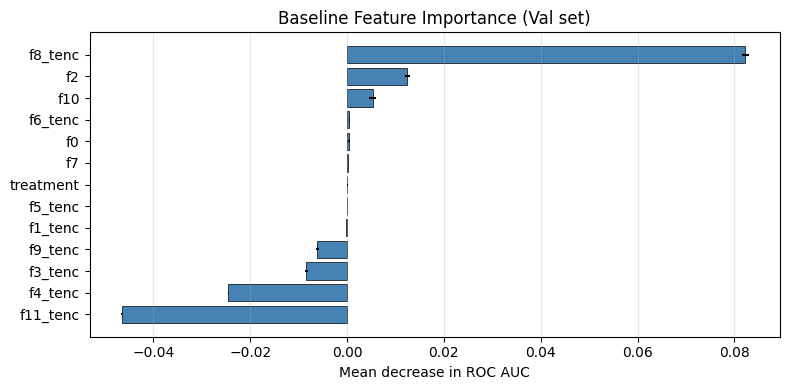

In [ ]:
# Stack treatment column to feature matrix and fit a simple baseline model
y_train_bin = (Y_r_train == 1)
X_train_with_T = np.hstack([X_train, T_train.reshape(-1, 1)])

model = HistGradientBoostingClassifier(random_state=1, categorical_features=cat_feature_indices)
model.fit(X_train_with_T, y_train_bin)

y_pred = model.predict_proba(X_train_with_T)[:, 1]
print(f"Train  AUC: {roc_auc_score(y_train_bin, y_pred):.4f}, "
      f"F1: {f1_score(y_train_bin, model.predict(X_train_with_T)):.4f}")

if X_val is not None:
    X_eval = np.hstack([X_val, T_val.reshape(-1, 1)]); y_eval = (Y_r_val == 1); lbl = "Val"
else:
    X_eval = np.hstack([X_test, T_test.reshape(-1, 1)]); y_eval = (Y_r_test == 1); lbl = "Test"

y_eval_pred = model.predict_proba(X_eval)[:, 1]
print(f"{lbl:5s}  AUC: {roc_auc_score(y_eval, y_eval_pred):.4f}, "
      f"F1: {f1_score(y_eval, model.predict(X_eval)):.4f}")

# Permutation importance
feature_names = all_feature_cols + ["treatment"]
perm_imp = permutation_importance(model, X_eval, y_eval, n_repeats=3, random_state=1, scoring="roc_auc")
sorted_idx = np.argsort(perm_imp.importances_mean)

fig, ax = plt.subplots(figsize=(8, max(4, len(feature_names) * 0.3)))
ax.barh([feature_names[i] for i in sorted_idx], perm_imp.importances_mean[sorted_idx],
        xerr=perm_imp.importances_std[sorted_idx], color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Mean decrease in ROC AUC")
ax.set_title(f"Baseline Feature Importance ({lbl} set)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

## 5. Causal Models: SLearner & NonParamDML (R-learner)

In [ ]:
# SLearner (default)
# ────────────────────────────────────────────────────────────────────────────────────
# SLEARNER: Single Learner (Meta-Learner)
# ────────────────────────────────────────────────────────────────────────────────────
# SLearner is one of the simplest causal meta-learners:
#   1. Train a single model: Y ~ X + T (includes treatment as a feature)
#   2. Compute CATE: Ŷ(X, T=1) - Ŷ(X, T=0)
#   3. Pros: Simple, captures smooth treatment effects, good when treatment is exogenous
#   4. Cons: May struggle if confounding or strong non-linearities in Y(T) relationship
# ────────────────────────────────────────────────────────────────────────────────────

t0 = time.time()
model_sl = SLearner(overall_model=HistGradientBoostingRegressor(random_state=1))
model_sl.fit(Y_r_train, T_train, X=X_train)
ate_sl_test = np.asarray(model_sl.ate(X_test)).item()
print(f"SLearner ATE     train: {np.asarray(model_sl.ate(X_train)).item():.6f}, test: {ate_sl_test:.6f}  ({time.time()-t0:.1f}s)")

# NonParamDML (default) 
# ────────────────────────────────────────────────────────────────────────────────────
# NONPARAMETRIC DML (DOUBLE MACHINE LEARNING / R-LEARNER)
# ────────────────────────────────────────────────────────────────────────────────────
# NonParamDML implements the DML framework with non-parametric final stage:
#   1. Estimate propensity: P(T=1|X) via model_t (then residuals: T̃ = T - P(T|X))
#   2. Estimate outcome: E[Y|X] via model_y (then residuals: Ỹ = Y - E[Y|X])
#   3. Regress residuals: Ỹ ~ T̃ via model_final to estimate CATE
#   4. Pros: Debiased estimator, robust to confounding, orthogonal to nuisance parameters
#   5. Cons: Higher variance, requires balancing act between models
#
# Model strategy:
#   - model_y: Tuned (outcome classifier)
#   - model_t: FIXED = SIMPLE_T_PARAMS (propensity; no tuning needed for 50/50 A/B test)
#   - model_final: Tuned (final CATE regression; usually weak learner)
# ────────────────────────────────────────────────────────────────────────────────────

t0 = time.time()
model_dml = NonParamDML(
    model_y=HistGradientBoostingClassifier(random_state=1),
    model_t=HistGradientBoostingClassifier(**SIMPLE_T_PARAMS),
    model_final=HistGradientBoostingRegressor(random_state=1),
    discrete_treatment=True,
    discrete_outcome=True,
    random_state=1)
model_dml.fit(Y_r_train, T_train, X=X_train)
ate_dml_test = np.asarray(model_dml.ate(X_test)).item()
print(f"NonParamDML ATE  train: {np.asarray(model_dml.ate(X_train)).item():.6f}, test: {ate_dml_test:.6f}  ({time.time()-t0:.1f}s)")
print(f"  (discrete_treatment=True, discrete_outcome=True)")

# CATE on test
sl_cate_test = model_sl.effect(X_test).flatten()
dml_cate_test = model_dml.effect(X_test).flatten()
print(f"\nSLearner CATE:       mean={sl_cate_test.mean():.6f}, std={sl_cate_test.std():.6f}")
print(f"NonParamDML CATE:    mean={dml_cate_test.mean():.6f}, std={dml_cate_test.std():.6f}")

SLearner ATE     train: 0.000506, test: 0.000503  (32.3s)
NonParamDML ATE  train: 0.000925, test: 0.000920  (75.3s)
  (discrete_treatment=True, discrete_outcome=True)

SLearner CATE:       mean=0.000503, std=0.003494
NonParamDML CATE:    mean=0.000920, std=0.007171


*Notes: For both models, the std deviations are ~7 times larger than the means. This means that there is a high variance among the user's treatment effect, and that the treatment is highly effective for some users, but useless for others. 

## 6. Hyperparameter Tuning

The model is first trained on the training set, then tuned on the validation set, and finally tested on the test set. The validation metric is uplift at 20% since we are targeting the top 20% of persuadables.

At each tuning trial:
1. Optuna fits a combination of model parameters and train the model on training set.
2. It then predicts the CATE of each user in the val dataset.
3. Next, it ranks the users by CATE in descending order.
4. Finally, it looks at the top 20% of users and calculate the validation score (mean conversion rate of treated in top 20% - mean conversion rate of control in top 20%) 


In [24]:
# Binarise outcomes 
y_train_bin_tune = Y_r_train > 0
y_val_bin_tune = Y_r_val > 0
y_true_bin = Y_r_test > 0


# Validation Scoring Function 
def score_on_validation(cate_val, Y_val_bin, T_val, k_pct=OPTIMISE_K):
    """Score model CATE on validation set using Uplift@K%.
    
    Parameters
    ----------
    cate_val : array-like
        Predicted Conditional Average Treatment Effect (CATE) on validation set
    Y_val_bin : array-like
        Binary outcome on validation set
    T_val : array-like
        Binary treatment on validation set
    k_pct : float, default=OPTIMISE_K
        Percentage of users to treat (select top K% by CATE)
    
    Returns
    -------
    float
        Uplift@K% = (CVR_treated - CVR_control) in the top K% segment
        Returns 0.0 if validation set has no treatment or control samples
    """
    n_select = max(1, int(len(cate_val) * k_pct / 100))
    top_idx = np.argsort(cate_val)[::-1][:n_select]
    t_top, y_top = T_val[top_idx], Y_val_bin[top_idx]
    if (t_top == 1).sum() == 0 or (t_top == 0).sum() == 0:
        return 0.0
    return y_top[t_top == 1].mean() - y_top[t_top == 0].mean()


print(f"Tuning: separate validation set (encoder fit on train only)")
print(f"Objective: Uplift@{OPTIMISE_K}%")

Tuning: separate validation set (encoder fit on train only)
Objective: Uplift@20%


### 6a. SLearner

In [25]:
def objective_sl(trial):
    params = {
        "max_depth":        trial.suggest_int("max_depth", 2, 9),
        "max_leaf_nodes":   trial.suggest_int("max_leaf_nodes", 8, 128, log=True),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 500, log=True),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
    }
    sl = SLearner(overall_model=HistGradientBoostingRegressor(random_state=1, **params))
    sl.fit(Y_r_train, T_train, X=X_train)
    return score_on_validation(sl.effect(X_val).flatten(), y_val_bin_tune, T_val)

study_sl = optuna.create_study(direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=20))
study_sl.optimize(objective_sl, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nSLearner best Uplift@{OPTIMISE_K}% (validation): {study_sl.best_value:.6f}")
print(f"Best hyperparameters: {study_sl.best_params}")

# ── Refit best SLearner on full train ─────────────────────────────────────────
best_params_sl = study_sl.best_params
model_sl_tuned = SLearner(
    overall_model=HistGradientBoostingRegressor(random_state=1, **best_params_sl))
model_sl_tuned.fit(Y_r_train, T_train, X=X_train)

sl_cate_test_tuned = model_sl_tuned.effect(X_test).flatten()
qini_test_sl_tuned = qini_auc_score(y_true_bin, sl_cate_test_tuned, T_test)
ate_sl_test_tuned = np.asarray(model_sl_tuned.ate(X_test)).item()
_n_sel = max(1, int(len(sl_cate_test_tuned) * OPTIMISE_K / 100))
_top = np.argsort(sl_cate_test_tuned)[::-1][:_n_sel]
_uplift_sl = (y_true_bin[_top][T_test[_top]==1].mean() - y_true_bin[_top][T_test[_top]==0].mean()) * 100
print(f"Test set: Qini AUC={qini_test_sl_tuned:.4f}, ATE={ate_sl_test_tuned:.6f}, Uplift@{OPTIMISE_K}%={_uplift_sl:+.2f}pp")

Best trial: 20. Best value: 0.00517547: 100%|██████████| 40/40 [24:34<00:00, 36.87s/it]



SLearner best Uplift@20% (validation): 0.005175
Best hyperparameters: {'max_depth': 7, 'max_leaf_nodes': 22, 'min_samples_leaf': 444, 'learning_rate': 0.07900696543282952}
Test set: Qini AUC=0.1908, ATE=0.000629, Uplift@20%=+0.51pp


### 6b. NonParamDML (R-learner)

In [26]:
def objective_dml(trial):
    params_y = {
        "max_depth":        trial.suggest_int("y_max_depth", 2, 9),
        "max_leaf_nodes":   trial.suggest_int("y_max_leaf_nodes", 8, 128, log=True),
        "min_samples_leaf": trial.suggest_int("y_min_samples_leaf", 10, 500, log=True),
        "learning_rate":    trial.suggest_float("y_learning_rate", 0.005, 0.3, log=True),
    }
    params_final = {
        "max_depth":        trial.suggest_int("final_max_depth", 2, 9),
        "max_leaf_nodes":   trial.suggest_int("final_max_leaf_nodes", 8, 128, log=True),
        "min_samples_leaf": trial.suggest_int("final_min_samples_leaf", 10, 500, log=True),
        "learning_rate":    trial.suggest_float("final_learning_rate", 0.005, 0.3, log=True),
    }
    factory = lambda: NonParamDML(
        model_y=HistGradientBoostingClassifier(random_state=1, **params_y),
        model_t=HistGradientBoostingClassifier(**SIMPLE_T_PARAMS),
        model_final=HistGradientBoostingRegressor(random_state=1, **params_final),
        discrete_treatment=True,
        discrete_outcome=True,
        random_state=1)
    dml = factory()
    dml.fit(Y_r_train, T_train, X=X_train)
    return score_on_validation(dml.effect(X_val).flatten(), y_val_bin_tune, T_val)

study_dml = optuna.create_study(direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=20))
study_dml.optimize(objective_dml, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nNonParamDML best Uplift@{OPTIMISE_K}% (validation): {study_dml.best_value:.6f}")
print(f"Best hyperparameters: {study_dml.best_params}")
print(f"Propensity model (model_t): Fixed classifier {SIMPLE_T_PARAMS}")

# ── Refit best NonParamDML on full train ──────────────────────────────────────
best_params_dml = study_dml.best_params
params_y_best = {k.replace("y_", ""): v for k, v in best_params_dml.items() if k.startswith("y_")}
params_final_best = {k.replace("final_", ""): v for k, v in best_params_dml.items() if k.startswith("final_")}

model_dml_tuned = NonParamDML(
    model_y=HistGradientBoostingClassifier(random_state=1, **params_y_best),
    model_t=HistGradientBoostingClassifier(**SIMPLE_T_PARAMS),
    model_final=HistGradientBoostingRegressor(random_state=1, **params_final_best),
    discrete_treatment=True,
    discrete_outcome=True,
    random_state=1)
model_dml_tuned.fit(Y_r_train, T_train, X=X_train)

dml_cate_test_tuned = model_dml_tuned.effect(X_test).flatten()
qini_test_dml_tuned = qini_auc_score(y_true_bin, dml_cate_test_tuned, T_test)
ate_dml_test_tuned = np.asarray(model_dml_tuned.ate(X_test)).item()
_n_sel = max(1, int(len(dml_cate_test_tuned) * OPTIMISE_K / 100))
_top = np.argsort(dml_cate_test_tuned)[::-1][:_n_sel]
_uplift_dml = (y_true_bin[_top][T_test[_top]==1].mean() - y_true_bin[_top][T_test[_top]==0].mean()) * 100
print(f"Test set: Qini AUC={qini_test_dml_tuned:.4f}, ATE={ate_dml_test_tuned:.6f}, Uplift@{OPTIMISE_K}%={_uplift_dml:+.2f}pp")

Best trial: 36. Best value: 0.0049873: 100%|██████████| 40/40 [1:53:09<00:00, 169.73s/it] 



NonParamDML best Uplift@20% (validation): 0.004987
Best hyperparameters: {'y_max_depth': 5, 'y_max_leaf_nodes': 16, 'y_min_samples_leaf': 144, 'y_learning_rate': 0.03569770087471837, 'final_max_depth': 4, 'final_max_leaf_nodes': 10, 'final_min_samples_leaf': 135, 'final_learning_rate': 0.006292467030681439}
Propensity model (model_t): Fixed classifier {'max_depth': 3, 'max_leaf_nodes': 8, 'min_samples_leaf': 100, 'learning_rate': 0.1, 'random_state': 1}
Test set: Qini AUC=0.1703, ATE=0.000852, Uplift@20%=+0.51pp


## 7. Qini Evaluation

plots cumilative gain vs cumulative % of users treated, with perfect and random baselines for reference. 

SLearner (default)             Qini AUC: 0.1693
NonParamDML (default)          Qini AUC: 0.1594
SLearner (tuned)               Qini AUC: 0.1908
NonParamDML (tuned)            Qini AUC: 0.1703
Random baseline                Qini AUC: 0.0077


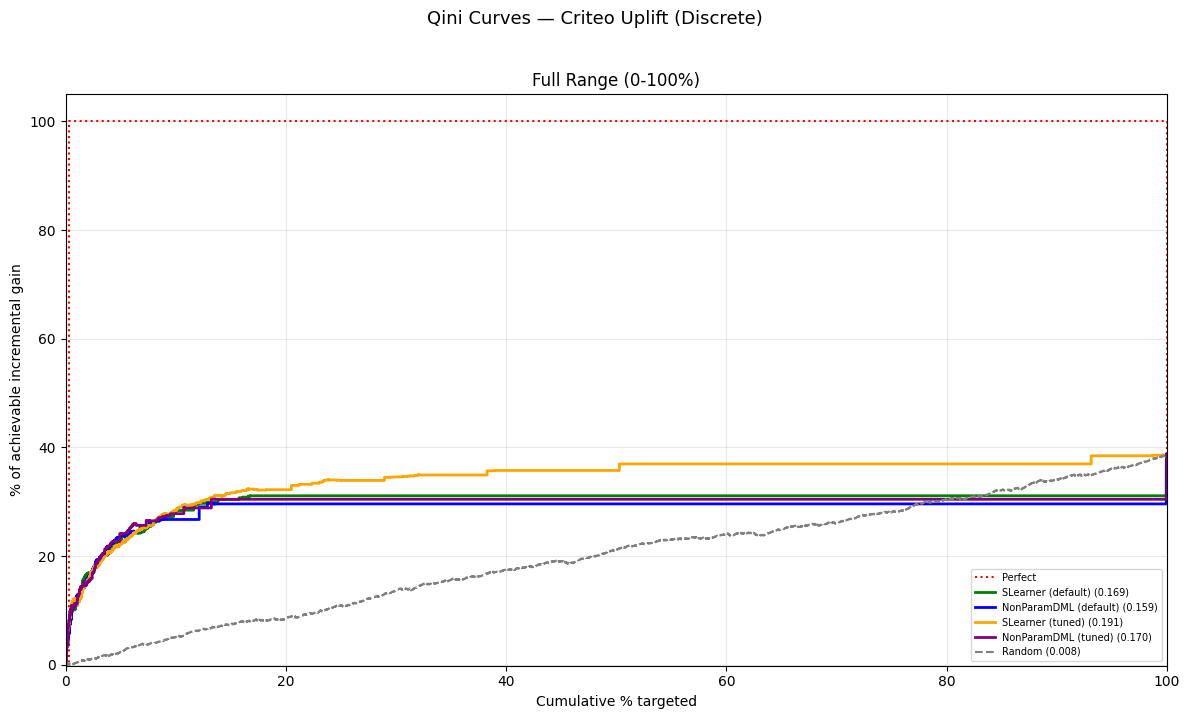


Test set: 2,795,919 obs, treat rate: 0.8502, CVR: 0.0030

                SLearner (default)   NonParamDML (default)        SLearner (tuned)     NonParamDML (tuned)
──────────────────────────────────────────────────────────────────────────────────────────────────────────
  Top   1%     847.7 (  29.4%)     919.1 (  31.8%)     818.2 (  28.3%)     844.0 (  29.2%)
  Top   2%    1239.3 (  42.9%)    1187.9 (  41.1%)    1154.2 (  40.0%)    1140.1 (  39.5%)
  Top   5%    1720.4 (  59.6%)    1766.9 (  61.2%)    1668.1 (  57.8%)    1800.3 (  62.3%)
  Top  10%    2114.2 (  73.2%)    1997.6 (  69.2%)    2120.4 (  73.4%)    2077.4 (  71.9%)
  Top  15%    2272.7 (  78.7%)    2211.7 (  76.6%)    2365.1 (  81.9%)    2275.0 (  78.8%)
  Top  20%    2323.3 (  80.5%)    2211.7 (  76.6%)    2407.4 (  83.4%)    2275.0 (  78.8%)
  Top  30%    2323.3 (  80.5%)    2211.7 (  76.6%)    2582.8 (  89.4%)    2275.0 (  78.8%)
  Top  50%    2323.3 (  80.5%)    2211.7 (  76.6%)    2671.6 (  92.5%)    2275.0 (  78.8%)

In [27]:
models_cate = {
    "SLearner (default)": sl_cate_test,
    "NonParamDML (default)": dml_cate_test,
    "SLearner (tuned)": sl_cate_test_tuned,
    "NonParamDML (tuned)": dml_cate_test_tuned,
}

y_train_bin_tune = Y_r_train > 0
y_true_bin = Y_r_test > 0

results = {}
for name, uplift in models_cate.items():
    ns, qv = qini_curve(y_true_bin, uplift, T_test)
    frac = ns / np.max(ns)
    qauc = qini_auc_score(y_true_bin, uplift, T_test)
    results[name] = {"fractions": frac, "qini_values": qv, "qini_auc": qauc}
    print(f"{name:30s} Qini AUC: {qauc:.4f}")

frac_perf, qv_perf = perfect_qini_curve(y_true_bin, T_test)
noise_uplift = rng.uniform(size=len(T_test))
ns_noise, qv_noise = qini_curve(y_true_bin, noise_uplift, T_test)
frac_noise = ns_noise / np.max(ns_noise)
noise_qini_auc = qini_auc_score(y_true_bin, noise_uplift, T_test)
print(f"{'Random baseline':30s} Qini AUC: {noise_qini_auc:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = {
    "SLearner (default)": "green",
    "NonParamDML (default)": "blue",
    "SLearner (tuned)": "orange",
    "NonParamDML (tuned)": "purple",
}
frac_perf_norm = frac_perf / np.max(frac_perf)

def plot_qini(ax, x_limit=None):
    ax.plot(frac_perf_norm * 100, 100 * qv_perf / np.max(qv_perf),
            label="Perfect", color="red", linewidth=1.5, linestyle=":", drawstyle="steps-post")
    worst_qv_norm = min(np.min(r["qini_values"]) for r in results.values()) / np.max(qv_perf)
    for name, data in results.items():
        ax.plot(data["fractions"] * 100, 100 * data["qini_values"] / np.max(qv_perf),
                label=f'{name} ({data["qini_auc"]:.3f})',
                color=colors[name], linewidth=2, drawstyle="steps-post")
    ax.plot(frac_noise * 100, 100 * qv_noise / np.max(qv_perf),
            label=f"Random ({noise_qini_auc:.3f})", color="gray", linestyle="--",
            linewidth=1.5, drawstyle="steps-post")
    ax.set_xlabel("Cumulative % targeted")
    ax.set_ylabel("% of achievable incremental gain")
    ax.set_ylim(100 * max(-1.05, worst_qv_norm), 105)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, x_limit or 100)

fig, ax = plt.subplots(figsize=(12, 7))
plot_qini(ax)
ax.set_title("Full Range (0-100%)")
ax.legend(loc="lower right", fontsize=7)
fig.suptitle("Qini Curves — Criteo Uplift (Discrete)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Gain at k% ───────────────────────────────────────────────────────────────
print(f"\nTest set: {len(T_test):,} obs, treat rate: {T_test.mean():.4f}, CVR: {y_true_bin.mean():.4f}")
model_names = list(results.keys())
print(f"\n{'':>10s}" + "".join(f"{n:>24s}" for n in model_names))
print("─" * (10 + 24 * len(model_names)))
for k in [1, 2, 5, 10, 15, 20, 30, 50, 100]:
    row = f"  Top {k:3d}%"
    for name in model_names:
        fracs, qvals = results[name]["fractions"], results[name]["qini_values"]
        q100 = qvals[-1]
        idx = np.searchsorted(fracs, k / 100, side="right") - 1
        qk = qvals[idx]
        pct = 100 * qk / q100 if q100 != 0 else float("nan")
        row += f"  {qk:8.1f} ({pct:6.1f}%)"
    print(row)

## 8. Decile Chart — Empirical Uplift by Predicted CATE Decile

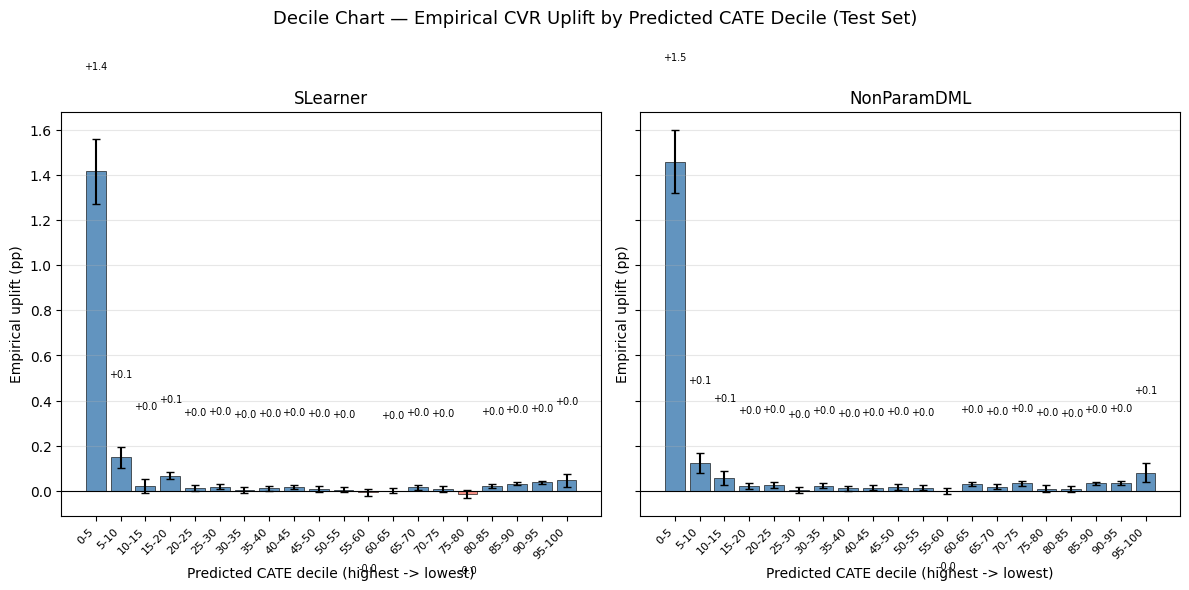


SLearner:
            n_treatment  n_control  response_rate_treatment  response_rate_control  uplift  std_treatment  std_control  std_uplift
percentile                                                                                                                        
0-5              121681      18115                   0.0467                 0.0326  0.0142         0.0006       0.0013      0.0015
5-10             119664      20132                   0.0050                 0.0035  0.0015         0.0002       0.0004      0.0005
10-15            118927      20869                   0.0017                 0.0015  0.0002         0.0001       0.0003      0.0003
15-20            119223      20573                   0.0009                 0.0002  0.0007         0.0001       0.0001      0.0001
20-25            118584      21212                   0.0004                 0.0003  0.0001         0.0001       0.0001      0.0001
25-30            118522      21274                   0.0004             

In [28]:
N_BINS = 20
y_test_int = y_true_bin.astype(int)
T_test_int = T_test.astype(int)

tuned_models_cate = {
    "SLearner": sl_cate_test,
    "NonParamDML": dml_cate_test,
}

fig, axes = plt.subplots(1, len(tuned_models_cate),
                         figsize=(6 * len(tuned_models_cate), 6), sharey=True)
if len(tuned_models_cate) == 1:
    axes = [axes]

for ax, (name, cate_arr) in zip(axes, tuned_models_cate.items()):
    cate_1d = np.asarray(cate_arr).ravel()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        df_dec = uplift_by_percentile(
            y_test_int, cate_1d, T_test_int,
            strategy="overall", bins=N_BINS, std=True,
            total=False, string_percentiles=True)

    x = np.arange(len(df_dec))
    uplift_vals = df_dec["uplift"].values
    std_vals = df_dec["std_uplift"].values if "std_uplift" in df_dec.columns else np.zeros(len(df_dec))
    bar_colors = ["steelblue" if u >= 0 else "salmon" for u in uplift_vals]

    ax.bar(x, uplift_vals * 100, yerr=std_vals * 100, capsize=3,
           color=bar_colors, edgecolor="black", linewidth=0.5, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(df_dec.index.tolist(), rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Predicted CATE decile (highest -> lowest)")
    ax.set_ylabel("Empirical uplift (pp)")
    ax.set_title(name)
    ax.grid(True, alpha=0.3, axis="y")
    for i, (val, s) in enumerate(zip(uplift_vals, std_vals)):
        ax.text(i, val * 100 + (s * 100 + 0.3) * np.sign(val + 1e-9),
                f"{val*100:+.1f}", ha="center",
                va="bottom" if val >= 0 else "top", fontsize=7)

fig.suptitle("Decile Chart — Empirical CVR Uplift by Predicted CATE Decile (Test Set)", fontsize=13)
plt.tight_layout(); plt.show()

for name, cate_arr in tuned_models_cate.items():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        df_tbl = uplift_by_percentile(
            y_test_int, np.asarray(cate_arr).ravel(), T_test_int,
            strategy="overall", bins=N_BINS, std=True,
            total=False, string_percentiles=True)
    print(f"\n{name}:")
    print(df_tbl.to_string(float_format="{:.4f}".format))

## 9. Summary

In [29]:
n_test = len(T_test)
base_conversion = y_true_bin[T_test == 0].mean()

def optimal_treat_pct(name):
    fracs, qvals = results[name]["fractions"], results[name]["qini_values"]
    best_frac = fracs[np.argmax(qvals)]
    return best_frac * 100, int(best_frac * n_test)

def empirical_uplift_at_k(cate_arr, pct):
    n_sel = max(1, int(len(cate_arr) * pct / 100))
    top = np.argsort(cate_arr)[::-1][:n_sel]
    sel_t, sel_c = T_test[top] == 1, T_test[top] == 0
    if sel_t.sum() == 0 or sel_c.sum() == 0:
        return float("nan"), float("nan"), float("nan")
    return (y_true_bin[top][sel_t].mean() - y_true_bin[top][sel_c].mean(),
            y_true_bin[top][sel_t].mean(), y_true_bin[top][sel_c].mean())

K_VALUES = [10, 20, 30, 50]
cate_arrays = {
    "SLearner (default)": sl_cate_test,
    "NonParamDML (default)": dml_cate_test,
    "SLearner (tuned)": sl_cate_test_tuned,
    "NonParamDML (tuned)": dml_cate_test_tuned,
}

rows = []
for name, ate_te in [("SLearner (default)", ate_sl_test),
                      ("NonParamDML (default)", ate_dml_test),
                        ("SLearner (tuned)", ate_sl_test_tuned),
                        ("NonParamDML (tuned)", ate_dml_test_tuned)
                      ]:
    qauc = results[name]["qini_auc"]
    pct, n = optimal_treat_pct(name)
    emp, cr_t, cr_c = empirical_uplift_at_k(cate_arrays[name], pct)
    uplift_k = {k: empirical_uplift_at_k(cate_arrays[name], k)[0] * 100 for k in K_VALUES}
    rows.append({
        "Model": name, "ATE (Test)": ate_te, "Qini AUC": qauc,
        "Opt % Treat": pct, "CR Ctrl (top-k)": cr_c, "CR Treat (top-k)": cr_t,
        "Emp Uplift (pp)": emp * 100,
        **{f"Uplift@{k}% (pp)": uplift_k[k] for k in K_VALUES},
    })

summary_df = pd.DataFrame(rows).set_index("Model")
print(summary_df.to_string(float_format="{:.4f}".format))

# Focused view
uplift_cols = [c for c in summary_df.columns if "Uplift@" in c]
print(f"\n{'-'*100}")
print(summary_df[["Qini AUC", "Emp Uplift (pp)"] + uplift_cols].to_string(float_format="{:.4f}".format))
print(f"\nBase CVR (control): {base_conversion:.4f} ({base_conversion*100:.2f}%)")
print(f"Random Qini AUC: {noise_qini_auc:.6f}")
print(f"Features ({len(all_feature_cols)}): {all_feature_cols}")

                       ATE (Test)  Qini AUC  Opt % Treat  CR Ctrl (top-k)  CR Treat (top-k)  Emp Uplift (pp)  Uplift@10% (pp)  Uplift@20% (pp)  Uplift@30% (pp)  Uplift@50% (pp)
Model                                                                                                                                                                           
SLearner (default)         0.0005    0.1693      99.9992           0.0019            0.0031           0.1215           0.8771           0.4966           0.3522           0.2241
NonParamDML (default)      0.0009    0.1594      99.9999           0.0019            0.0031           0.1215           0.8688           0.4928           0.3439           0.2169
SLearner (tuned)           0.0006    0.1908      99.9990           0.0019            0.0031           0.1215           0.8838           0.5129           0.3602           0.2317
NonParamDML (tuned)        0.0009    0.1703      99.9952           0.0019            0.0031           0.1223       

## 10. Feature Importance —  single learner tuned

  [██████████████████████████████] 12/12  done in 29.1s                              

NonParamDML (tuned) - CATE Permutation Importance (test set)
 rank  feature  importance  pct_of_max
    1      f10    0.011589  100.000000
    2       f0    0.009650   83.269803
    3       f7    0.006181   53.329650
    4  f3_tenc    0.006142   53.000433
    5  f8_tenc    0.006064   52.326899
    6  f5_tenc    0.006031   52.042688
    7       f2    0.005852   50.498785
    8  f9_tenc    0.005817   50.192721
    9  f4_tenc    0.005728   49.426048
   10  f1_tenc    0.005140   44.349325
   11  f6_tenc    0.005058   43.647195
   12 f11_tenc    0.004917   42.427275


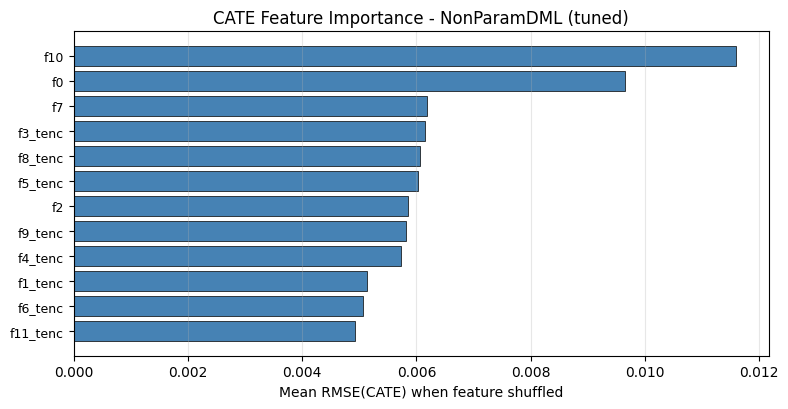

In [31]:
import time as _time

n_repeats_perm = 5
rng_perm = np.random.RandomState(42)
cate_ref = model_sl_tuned.effect(X_test).flatten()

n_feats = len(all_feature_cols)
importances = {}
t_start = _time.time()

for j, feat in enumerate(all_feature_cols):
    deltas = []
    for _ in range(n_repeats_perm):
        X_perm = X_test.copy()
        X_perm[:, j] = rng_perm.permutation(X_perm[:, j])
        cate_perm = model_dml.effect(X_perm).flatten()
        deltas.append(np.mean((cate_ref - cate_perm)**2)**0.5)
    importances[feat] = np.mean(deltas)
    done = j + 1
    elapsed = _time.time() - t_start
    eta = elapsed / done * (n_feats - done)
    filled = int(30 * done / n_feats)
    bar = "█" * filled + "░" * (30 - filled)
    print(f"\r  [{bar}] {done}/{n_feats}  {feat:<30s}  ETA {eta:.0f}s", end="", flush=True)

print(f'\r  [{"█" * 30}] {n_feats}/{n_feats}  done in {_time.time() - t_start:.1f}s' + " " * 30)

imp_df = (pd.DataFrame({"feature": list(importances.keys()),
                         "importance": list(importances.values())})
          .sort_values("importance", ascending=False).reset_index(drop=True))
imp_df["rank"] = imp_df.index + 1
imp_df["pct_of_max"] = 100 * imp_df["importance"] / imp_df["importance"].iloc[0]

print("\nNonParamDML (tuned) - CATE Permutation Importance (test set)")
print("=" * 80)
print(imp_df[["rank", "feature", "importance", "pct_of_max"]].to_string(
    index=False, float_format="{:.6f}".format))

fig, ax = plt.subplots(figsize=(8, max(4, n_feats * 0.35)))
ax.barh(np.arange(len(imp_df)), imp_df["importance"].values,
        color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_yticks(np.arange(len(imp_df)))
ax.set_yticklabels(imp_df["feature"].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Mean RMSE(CATE) when feature shuffled")
ax.set_title("CATE Feature Importance - NonParamDML (tuned)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

# Conclusion 

#### Final Model
- Based on the notebook’s CATE and Qini analysis, the best final model is: SLearner (tuned)

#### Why
- It has the highest test-set Qini AUC, in which a higher Qini AUC means it ranks customers by uplift more accurately, which is the most important criterion for an uplift model:
   - SLearner (tuned) = 0.19
   - NonParamDML (tuned) = 0.17


- Its top-decile uplift is also strongest: 
   - `Uplift@20%` = `+0.51 pp` vs `+0.50 pp` (NonParamDML tuned)      
   - `Uplift@30%` = `+0.36 pp` vs `+0.35 pp` (NonParamDML tuned)   
   - `Uplift@50%` = `+0.23 pp` vs `+0.22 pp` (NonParamDML tuned)  

#### Additional observations
- Both tuned models beat their default versions.
- The tuned models’ empirical average uplift is very similar, but the tuned SLearner has a clearer edge in ranking quality.
- Control base CVR is very low (0.19%), so correctly identifying the high-uplift segment is especially important.